In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [ ]:

df = pd.read_csv('fetal_health.csv')
df.head()


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

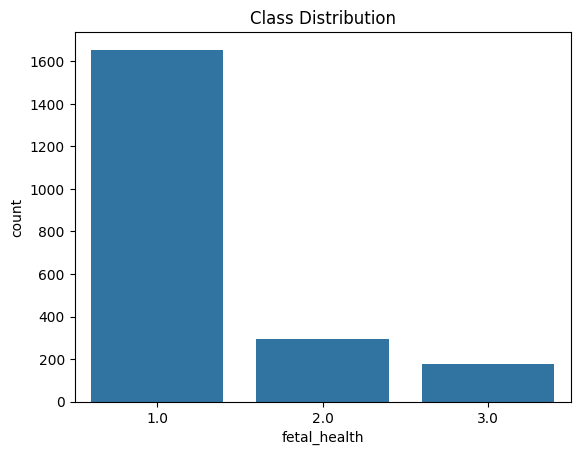

In [ ]:

df.info()
print(df.isnull().sum())
df.describe()
sns.countplot(x='fetal_health', data=df)
plt.title('Class Distribution')
plt.show()


In [ ]:

X = df.drop('fetal_health', axis=1)
y = df['fetal_health']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (1700, 21)
X_test shape: (426, 21)


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# one-hot encode again (if needed)
y_train_cat = to_categorical(y_train - 1)
y_test_cat = to_categorical(y_test - 1)


classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = {i: w for i, w in zip(classes, class_weights)}
print("Class Weights:", class_weights_dict)


model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# early stopping (prevents overfitting)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# train
history = model.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=60,
    batch_size=32,
    class_weight=class_weights_dict,
    verbose=1,
    callbacks=[early_stop]
)



Class Weights: {np.float64(1.0): np.float64(0.42831947593852354), np.float64(2.0): np.float64(2.401129943502825), np.float64(3.0): np.float64(4.0189125295508275)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,251 (51.76 KB)

 Trainable params: 13,251 (51.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.6819 - loss: 0.9513 - val_accuracy: 0.8294 - val_loss: 0.5460
Epoch 2/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8144 - loss: 0.4938 - val_accuracy: 0.8353 - val_loss: 0.3939
Epoch 3/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8400 - loss: 0.3351 - val_accuracy: 0.8647 - val_loss: 0.2996
Epoch 4/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8348 - loss: 0.3255 - val_accuracy: 0.8647 - val_loss: 0.3005
Epoch 5/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8411 - loss: 0.2884 - val_accuracy: 0.8529 - val_loss: 0.3081
Epoch 6/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8555 - loss: 0.2659 - val_accuracy: 0.8706 - val_loss: 0.2867
Epoch 7/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8509 - loss: 0.2495 - val_accuracy: 0.8647 - val_loss: 0.2891
Epoch 8/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8489 - loss: 0.2421 - val_accuracy: 0.8618 - val_loss

In [15]:
history = model.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)


Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9016 - loss: 0.2352 - val_accuracy: 0.9294 - val_loss: 0.1652
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9255 - loss: 0.1824 - val_accuracy: 0.9118 - val_loss: 0.1662
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9080 - loss: 0.1946 - val_accuracy: 0.9265 - val_loss: 0.1613
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9060 - loss: 0.2070 - val_accuracy: 0.9353 - val_loss: 0.1489
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9168 - loss: 0.1827 - val_accuracy: 0.9265 - val_loss: 0.1505
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9329 - loss: 0.1610 - val_accuracy: 0.9147 - val_loss: 0.1580
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9318 - loss: 0.1497 - val_accuracy: 0.9324 - val_loss: 0.1482
Epoch 8/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9306 - loss: 0.1638 - val_accuracy: 0.9294 - val_loss

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
Test Accuracy: 0.9107981220657277


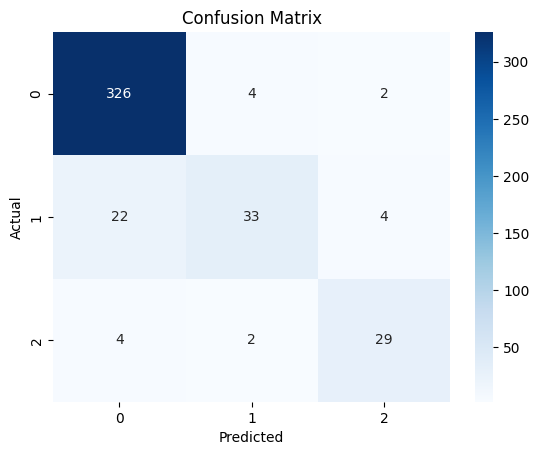

              precision    recall  f1-score   support

      Normal       0.93      0.98      0.95       332
     Suspect       0.85      0.56      0.67        59
Pathological       0.83      0.83      0.83        35

    accuracy                           0.91       426
   macro avg       0.87      0.79      0.82       426
weighted avg       0.91      0.91      0.90       426



In [16]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) + 1
print("Test Accuracy:", accuracy_score(y_test, y_pred_classes))
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
print(classification_report(y_test, y_pred_classes, target_names=['Normal', 'Suspect', 'Pathological']))


In [ ]:

model.save('FHR_nn_model.h5')
import joblib
joblib.dump(scaler, 'FHR_scaler.pkl')
from google.colab import files
files.download('FHR_nn_model.h5')
files.download('FHR_scaler.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


In [4]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('fetal_health.csv')

X = df.drop('fetal_health', axis=1)
y = df['fetal_health']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(" Data ready:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


 Data ready:
X_train shape: (1700, 21)
X_test shape: (426, 21)


In [12]:
from xgboost import XGBClassifier

# Adjust labels: convert 1,2,3 → 0,1,2
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

# Initialize XGBoost model
xgb = XGBClassifier(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=2,
    random_state=40,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Train the model
xgb.fit(X_train, y_train_xgb)

print("✅ XGBoost training successful!")


✅ XGBoost training successful!


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:43:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 XGBoost Test Accuracy: 90.61%


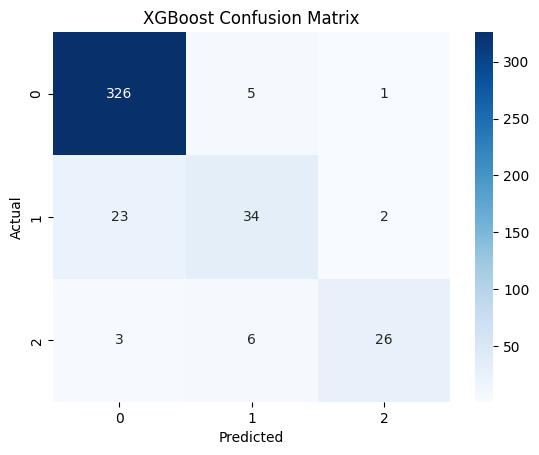


Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.98      0.95       332
     Suspect       0.76      0.58      0.65        59
Pathological       0.90      0.74      0.81        35

    accuracy                           0.91       426
   macro avg       0.86      0.77      0.81       426
weighted avg       0.90      0.91      0.90       426



In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
y_pred_xgb = xgb.predict(X_test)
acc_xgb = accuracy_score(y_test_xgb, y_pred_xgb)
print(f" XGBoost Test Accuracy: {acc_xgb*100:.2f}%")
cm = confusion_matrix(y_test_xgb, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()
print("\nClassification Report:")
print(classification_report(y_test_xgb, y_pred_xgb, target_names=['Normal', 'Suspect', 'Pathological']))


In [9]:
import numpy as np

sample_input = np.array([[128.0, 0.005, 0.002, 0.004, 0.0, 0.0, 0.0, 50.0, 15.0, 0.5,
                          25.0, 7.0, 100.0, 120.0, 5.0, 10.0, 3.0, 8.0, 6.0, 30.0, 0.4]])
from sklearn.preprocessing import StandardScaler
scaled_input = scaler.transform(sample_input)
pred = xgb.predict(scaled_input)
classes = {0: 'Normal', 1: 'Suspect', 2: 'Pathological'}
print(" Predicted Fetal Health:", classes[int(pred[0])])


 Predicted Fetal Health: Normal


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
